# Neural Posterior Estimation for LISA
## Part 2b — The DINGO pipeline

**AI for LISA Hackathon @ ESTEC — tutorial by Stephen Green (Tuesday)**

Parts 1 and 2a built neural posterior estimation by hand. However, complexity began to grow
*around* the method: prior bounds, standardization constants, checkpoint names, epoch counts, which flag meant
what, which file went with which network. [DINGO](https://github.com/dingo-gw/dingo) keeps track of these complexities. It generates training data, trains networks, and runs inference. Right now, DINGO works primarily for LVK binaries, but with some extensions to ET and LISA (see Alice's talk).

| | | |
|---|---|---|
| 1 | What you have been managing by hand | ~1 min |
| 2 | One settings file per thing on that list | ~3 min |
| 3 | A run, end to end | ~15 min |
| 4 | The same code at production scale | ~5 min |

### Before you start

This one is a demo rather than an exercise. It drives a command line, and the outputs below are stored.
Reproducing it needs `pip install dingo-gw` and about 3 GB of disk, nearly all of it the waveform dataset; the
in-session demo accounts for about 200 MB of that. The settings files live in `dingo/` in this repository; the
run directory sits *outside* it, because waveform datasets are large. The network used from section 3.4
onwards was trained in about four hours on one NVIDIA A100. The cells that run live in the session run on the
laptop CPU, and the text says which is which.

In [1]:
# On a bare Colab runtime, install DINGO first: it pulls LALSuite, bilby and gwpy, and takes a
# few minutes. A no-op wherever dingo-gw is already installed.
import importlib.util
import sys

if importlib.util.find_spec("dingo") is None:
    !{sys.executable} -m pip install -q dingo-gw

import io
import os
import shutil
import subprocess
import sys
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, SVG, Image, Markdown, display

# IPython turns on LAL's SWIG stdout redirection, which costs a factor of ~25 in
# waveform generation and so in importance sampling. Turn it back off.
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
lal.swig_redirect_standard_output_error(False)

# bilby scores its mass constraints by taking log of a boolean array, so every batch of
# samples with one out-of-bounds point raises. That is the intended path.
warnings.filterwarnings("ignore", "divide by zero encountered in log")

import dingo

# DINGO's command-line tools are installed next to the interpreter running this notebook.
os.environ["PATH"] = f"{Path(sys.executable).parent}{os.pathsep}{os.environ['PATH']}"

SETTINGS = Path("dingo").resolve()                      # settings files, in the repo
MODEL = Path("checkpoints/part2b_toy.pt").resolve()     # 11 parameters, four hours on one A100
RUN = Path("../dingo-training/bbh_11d_a100")            # that network's run directory, outside the repo
RUN = RUN.resolve()
ASDS = RUN / "training_data/asd_dataset/asds_O1.hdf5"   # O1 noise, shared by every run in this notebook
DEMO = Path("../dingo-training/demo").resolve()         # scratch space for the live demo below
RESULTS = Path("results/GW150914").resolve()            # dingo_pipe output, committed
GWTC1 = Path("results/GW150914_GWTC-1.hdf5").resolve()  # the LVC sample release, used in section 4

HOME = str(Path.home())

MAX_LINES = 800     # print guard: longer output is cut in the middle, and says so


class _Tidied:
    """A stream proxy that rewrites this machine's home directory to ~ on the way past."""

    def __init__(self, stream):
        self._stream = stream

    def write(self, text):
        return self._stream.write(text.replace(HOME, "~"))

    def __getattr__(self, name):
        return getattr(self._stream, name)


@contextmanager
def tidy_paths():
    """DINGO announces every file it opens by absolute path. Those paths are true on the
    laptop that ran this and nowhere else, so keep them out of the stored output."""
    old_out, old_err = sys.stdout, sys.stderr
    sys.stdout, sys.stderr = _Tidied(old_out), _Tidied(old_err)
    try:
        yield
    finally:
        sys.stdout, sys.stderr = old_out, old_err


def show_lines(lines, max_lines=MAX_LINES):
    """Print output in full, unless there is more of it than `max_lines`: then cut the
    middle out and say how many lines went."""
    lines = [line.replace(HOME, "~") for line in lines]
    if not lines:
        print("(no output)")
    elif len(lines) <= max_lines:
        print("\n".join(lines))
    else:
        half = max_lines // 2
        print("\n".join(lines[:half]))
        print(f"\n[... {len(lines) - 2 * half} of {len(lines)} lines omitted here ...]\n")
        print("\n".join(lines[-half:]))


def sh(cmd, cwd, max_lines=MAX_LINES):
    """Run a DINGO command line, echoing it, and print everything it printed.

    Parameters
    ----------
    cmd : str
        The command line, as you would type it.
    cwd : Path
        Directory to run it in.
    max_lines : int, optional
        Longer output is cut in the middle, via `show_lines`.

    Returns
    -------
    float
        Wall time of the command [s].
    """
    print(f"$ {cmd}")
    t0 = time.time()
    p = subprocess.run(cmd, shell=True, cwd=cwd, text=True,
                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    show_lines(p.stdout.splitlines(), max_lines)
    dt = time.time() - t0
    print(f"[exit {p.returncode}, {dt:.0f} s]")
    return dt


def show_file(path, lang="yaml"):
    """Render a settings file as a bordered card: filename bar on top, highlighted body.

    Parameters
    ----------
    path : str or Path
        File to display.
    lang : str, optional
        Pygments lexer name for the highlighting.
    """
    from pygments import highlight
    from pygments.formatters import HtmlFormatter
    from pygments.lexers import get_lexer_by_name

    text = Path(path).read_text().rstrip().replace(HOME, "~")
    body = highlight(text, get_lexer_by_name(lang), HtmlFormatter(noclasses=True, nobackground=True))
    display(HTML(
        '<div style="border:1.5px solid #999;border-radius:6px;overflow:hidden;margin:6px 0">'
        f'<div style="background:#e8e8e8;padding:4px 12px;font-family:monospace;font-size:85%;'
        f'font-weight:bold;border-bottom:1.5px solid #999">{Path(path).name}</div>'
        f'<div style="padding:2px 12px;background:#fbfbfb;font-size:85%;overflow-x:auto">{body}</div>'
        '</div>'))
print(f"dingo {dingo.__version__}")

dingo 0.9.8


---
# 1. What you have been managing by hand

*(~1 min)*

- prior bounds `PRIOR_LOW`, `PRIOR_HIGH`, and a retyped second copy, `P1_LOW`, `P1_HIGH`, in Part 2a
- parameter order, held in four parallel lists: the slicing inside `gb_envelope`, `LABELS`, `PLOT_SCALE`, `names`
- simulator constants `YEAR`, `T_OBS`, `N`, `F_REF`, `R_AU_C`, `BETA`, `LAM`, `NOISE_STD`, in four copies
  (Part 1's cell, `gb_simulator.py`, Part 2a's cell, `gb_wide.py`)
- `THETA_MEAN`, `THETA_STD`: computed at dataset construction, undone by hand at five separate inference sites,
  retyped in Part 2a as `P1_MEAN`, `P1_STD`, with the Jacobian `- torch.log(P1_STD).sum()` applied by hand
  before importance sampling
- network and training settings scattered over two notebooks: `num_flow_steps`, `hidden_dim`,
  `base_transform_type`, `CONTEXT_DIM`, `lr`, `CosineAnnealingLR(T_max=epochs)`, `BATCH_SIZE`, `N_TRAIN`
- `N_EPOCHS = 128` in Part 1's notebook, 64 in the shipped checkpoint, recorded in a comment; four flags
  (`TRAIN_LIVE`, `CHECKPOINT`, `TRAIN_LIVE_EX`, `EX_CHECKPOINT`) to say which one you get
- what a checkpoint holds: `state_dict`, `history`, `n_epochs`, `device`, and in Part 2a also `seconds`, so the
  two dicts are not interchangeable
- conditioning and importance sampling: `W_WIDE`, `R`, `N_WIDE`, `DF_P1`, the half-sample offset in `t_wide`,
  the demodulation shift undone by hand, `N_SCAN`, `N_FINAL`, two divergent `pp_plot` implementations, and
  seeds at seven separate points

---
# 2. One settings file per thing on that list

*(~3 min)*

DINGO has three settings files, and between them they hold every line above.

- `waveform_dataset_settings.yaml` — domain, waveform model, intrinsic prior, compression.
- `asd_dataset_settings.yaml` — observing run, detectors, how the PSD is estimated.
- `train_settings.yaml` — extrinsic prior, inference parameters, architecture, optimizer, schedule, stages.

What matters is what happens to those files afterwards. **Every file DINGO writes carries the settings that
produced it, composed with the settings of its inputs.** The waveform dataset stores its own generation
settings. The trained network stores those, plus its training settings, plus the standardization constants it
computed along the way. A result file stores all of that plus the event. Nothing is ever retyped, because
nothing is ever separated from its provenance, and reproducibility follows without anyone having to keep a
discipline.

Here is what you can read back out of a trained network.

In [2]:
from dingo.core.posterior_models.build_model import build_model_from_kwargs
from dingo.gw.dataset import WaveformDataset
from dingo.gw.training.train_builders import set_train_transforms

with tidy_paths():
    pm = build_model_from_kwargs(filename=str(MODEL), device="cpu", load_training_info=False)
    data_settings = pm.metadata["train_settings"]["data"]

    print("settings carried by the checkpoint:")
    for k, v in pm.metadata.items():
        print(f"  {k}: {list(v.keys())}")

    # The dataset knows its own domain and intrinsic prior; the network knows the rest. Between
    # them there is enough to rebuild the training-time data pipeline exactly.
    wfd = WaveformDataset(file_name=str(RUN / "training_data/waveform_dataset.hdf5"),
                          precision="single", leave_waveforms_on_disk=True)
    set_train_transforms(wfd, data_settings, str(ASDS))

print("\ninference parameters:", data_settings["inference_parameters"])

print("\ntraining transform chain:")
for i, t in enumerate(wfd.transform.transforms):
    print(f"  {i}. {type(t).__name__}")

print("\nparameter standardization, computed once and then carried along:")
std = data_settings["standardization"]
for p in ["chirp_mass", "chi_1", "luminosity_distance", "ra"]:
    print(f"  {p:22s} mean {std['mean'][p]:9.4f}   std {std['std'][p]:9.4f}")

Putting posterior model to device cpu.
settings carried by the checkpoint:
  dataset_settings: ['domain', 'waveform_generator', 'intrinsic_prior', 'num_samples', 'compression']
  train_settings: ['data', 'model', 'training']
Loading dataset from ~/Documents/Research/dingo-gw/tutorial-esa/dingo-training/bbh_11d_a100/training_data/waveform_dataset.hdf5.
Omitting data keys ['polarizations'].
Setting train transforms.
Loading dataset from ~/Documents/Research/dingo-gw/tutorial-esa/dingo-training/bbh_11d_a100/training_data/asd_dataset/asds_O1.hdf5.
Using previously-calculated parameter standardizations.

inference parameters: ['chirp_mass', 'mass_ratio', 'chi_1', 'chi_2', 'theta_jn', 'dec', 'ra', 'geocent_time', 'luminosity_distance', 'psi', 'phase']

training transform chain:
  0. SampleExtrinsicParameters
  1. GetDetectorTimes
  2. ProjectOntoDetectors
  3. SampleNoiseASD
  4. WhitenAndScaleStrain
  5. AddWhiteNoiseComplex
  6. SelectStandardizeRepackageParameters
  7. RepackageStrainsAnd

That chain is Part 1's `make_signal_set` and `GBDataset.__getitem__`, unrolled into nine named objects and
composed. Read it downwards: sample the extrinsic parameters the dataset never contained, work out the arrival
time at each detector, project the two polarizations onto H1 and L1, draw an ASD, whiten, add unit-variance
noise, standardize the parameters, pack strain and ASD into a tensor. Nothing you have not already written,
and nothing written twice, assembled *from the settings* rather than typed out.

`luminosity_distance` comes back with standard deviation 259.8, which is $900/\sqrt{12}$: the same
uniform-prior formula you wrote by hand in Part 1, computed once and thereafter carried by the checkpoint. We
are reading this pipeline rather than building one; Max opens that box on Thursday.

---
# 3. A run, end to end

*(~15 min)*

Four commands.

```
dingo_generate_dataset      --settings_file waveform_dataset_settings.yaml --out_file waveform_dataset.hdf5
dingo_generate_asd_dataset  --settings_file asd_dataset_settings.yaml      --data_dir asd_dataset
dingo_train                 --settings_file train_settings.yaml            --train_dir training
dingo_pipe                  GW150914.ini
```

Two of them run live in this notebook. The ASD dataset is a 130 MB download per detector, and `dingo_pipe`
takes about 25 minutes from cold, so those two are shown with their real settings files and their stored
output.

DINGO's *data* machinery — detectors, ASDs, frequency domains, GWOSC — is built for ground-based
interferometers, so the worked example here is a binary black hole rather than a galactic binary. Max's Thursday session
drives `dingo.core` on Tuesday's galactic binary. The network, the loss and the importance sampling are
the same objects either way.

The diagram below is the map for the rest of the notebook. Each section from here on opens by saying which box
it is standing in.

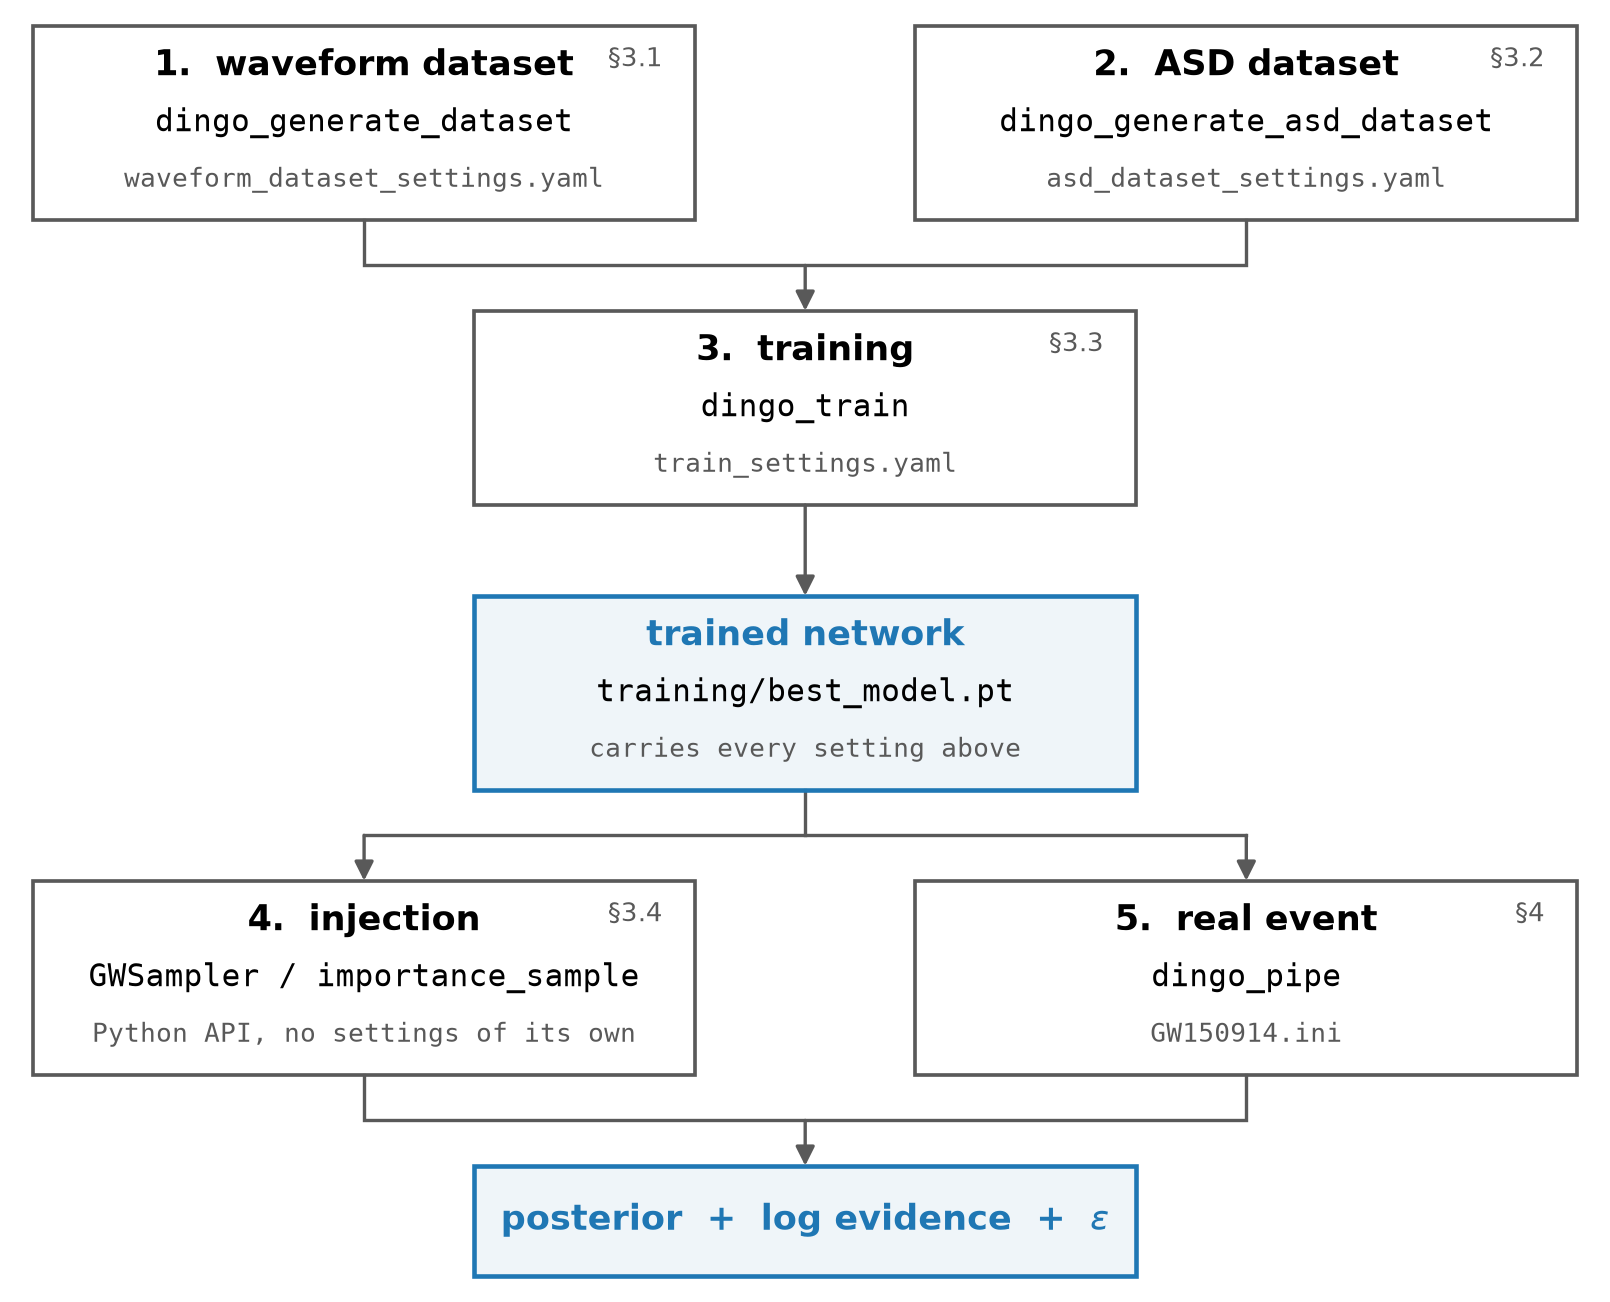

In [3]:
from matplotlib.patches import Rectangle

GRAY, ACC = "0.35", "C0"

fig, ax = plt.subplots(figsize=(7.2, 5.8))
ax.set_xlim(1.05, 8.95)      # the axes spans exactly the drawn content, so there
ax.set_ylim(0.10, 9.95)      # is no empty margin to crop
ax.axis("off")
fig.subplots_adjust(0, 0, 1, 1)


def box(x, y, w, h, title, cmd=None, cfg=None, sec=None, accent=False):
    """A plain rectangle: what the stage makes, the command that makes it, its settings file."""
    ec = ACC if accent else GRAY
    if accent:
        ax.add_patch(Rectangle((x, y), w, h, facecolor=ACC, alpha=0.07, linewidth=0, zorder=1))
    ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=ec,
                           linewidth=1.5 if accent else 1.2, zorder=2))
    rows = [(title, dict(fontsize=11.5, fontweight="bold", color=ec if accent else "black"))]
    if cmd:
        rows.append((cmd, dict(fontsize=10, family="monospace")))
    if cfg:
        rows.append((cfg, dict(fontsize=8.5, family="monospace", color=GRAY)))
    gap = 0.44                                    # one text row to the next
    y0 = y + h / 2 + gap * (len(rows) - 1) / 2    # center the rows in the box
    for i, (text, style) in enumerate(rows):
        ax.text(x + w / 2, y0 - i * gap, text, ha="center", va="center", zorder=3, **style)
    if sec:
        ax.text(x + w - 0.16, y + h - 0.16, f"§{sec}", ha="right", va="top",
                fontsize=8.5, color=GRAY, zorder=3)
    return {"cx": x + w / 2, "top": y + h, "bot": y}


def line(*pts):
    """An elbow, drawn behind the boxes."""
    ax.plot([p[0] for p in pts], [p[1] for p in pts], color=GRAY, lw=1.1,
            solid_joinstyle="miter", zorder=0)


def arrow(p0, p1):
    ax.annotate("", xy=p1, xytext=p0, zorder=0,
                arrowprops=dict(arrowstyle="-|>", color=GRAY, linewidth=1.1,
                                shrinkA=0, shrinkB=0, mutation_scale=13))


L, R, M, W, CX = 1.15, 5.55, 3.35, 3.3, 5.0   # left, right, middle column; width; center

A = box(L, 8.35, W, 1.5, "1.  waveform dataset", "dingo_generate_dataset",
        "waveform_dataset_settings.yaml", sec="3.1")
B = box(R, 8.35, W, 1.5, "2.  ASD dataset", "dingo_generate_asd_dataset",
        "asd_dataset_settings.yaml", sec="3.2")
C = box(M, 6.15, W, 1.5, "3.  training", "dingo_train", "train_settings.yaml", sec="3.3")
D = box(M, 3.95, W, 1.5, "trained network", "training/best_model.pt",
        "carries every setting above", accent=True)
E = box(L, 1.75, W, 1.5, "4.  injection", "GWSampler / importance_sample",
        "Python API, no settings of its own", sec="3.4")
F = box(R, 1.75, W, 1.5, "5.  real event", "dingo_pipe", "GW150914.ini", sec="4")
G = box(M, 0.20, W, 0.85, r"posterior  +  log evidence  +  $\epsilon$", accent=True)

bus = 8.00                                 # the two datasets go in together
line((A["cx"], A["bot"]), (A["cx"], bus), (B["cx"], bus), (B["cx"], B["bot"]))
arrow((CX, bus), (CX, C["top"]))

arrow((CX, C["bot"]), (CX, D["top"]))      # training makes the network

bus = 3.60                                 # the network, used two ways
line((CX, D["bot"]), (CX, bus))
line((E["cx"], bus), (F["cx"], bus))
arrow((E["cx"], bus), (E["cx"], E["top"]))
arrow((F["cx"], bus), (F["cx"], F["top"]))

bus = 1.40                                 # both give the same three things
line((E["cx"], E["bot"]), (E["cx"], bus), (F["cx"], bus), (F["cx"], F["bot"]))
arrow((CX, bus), (CX, G["top"]))

# Saved at high resolution and shown as a raster image: an untrusted notebook will not
# render inline SVG, and neither will GitHub. The same file goes into the slides.
SLIDES = Path("figures/for-slides")
SLIDES.mkdir(parents=True, exist_ok=True)
chart = SLIDES / "p2b_flowchart.png"
fig.savefig(chart, dpi=220, bbox_inches="tight", pad_inches=0.06)
plt.close(fig)
# Shown at the figure's natural size, so it sits at the same scale as the plots below.
display(Image(filename=str(chart), width=720, embed=True))

### 3.1 The waveform dataset

Stage 1 of the diagram. Intrinsic parameters only: extrinsic parameters are cheap, and DINGO samples them at
training time instead, which is what keeps the dataset small enough to build live. The `compression` block at
the bottom is a second economy: the waveforms are projected onto an SVD basis as they are generated, and the
command reports the mismatch that costs. Here is the settings file this notebook is about to hand to
`dingo_generate_dataset`, printed from disk.

In [4]:
DEMO.mkdir(parents=True, exist_ok=True)
for name in ["waveform_dataset_settings.yaml", "train_settings.yaml"]:
    (DEMO / name).write_text((SETTINGS / "demo" / name).read_text())

show_file(DEMO / "waveform_dataset_settings.yaml")

In [5]:
NPROC = 10
dt = sh(f"dingo_generate_dataset --settings_file waveform_dataset_settings.yaml "
        f"--num_processes {NPROC} --out_file waveform_dataset.hdf5", cwd=DEMO)

mb = (DEMO / "waveform_dataset.hdf5").stat().st_size / 1e6
print(f"{mb:.0f} MB for 5000 waveforms, held as coefficients on the 100-element SVD basis")
print(f"{dt:.0f} s on {NPROC} processes is about {NPROC * dt:.0f} core-seconds, "
      f"so roughly {NPROC * dt / 2 / 60:.0f} min on a two-core laptop")

$ dingo_generate_dataset --settings_file waveform_dataset_settings.yaml --num_processes 10 --out_file waveform_dataset.hdf5


Setting spin_conversion_phase = None. Using phase parameter for conversion to cartesian spins.
Generating dataset of size 1100
Building SVD basis.
n = 50
  Mean mismatch = 1.1073702782915528e-07
  Standard deviation = 5.294564330916084e-07
  Max mismatch = 5.229908005555117e-06
  Median mismatch = 2.6520140361530053e-08
  Percentiles:
    99    -> 1.166736597742986e-06
    99.9  -> 5.229908005533024e-06
    99.99 -> 5.229908005552908e-06
n = 100
  Mean mismatch = 1.714119352014265e-10
  Standard deviation = 7.093588413003506e-10
  Max mismatch = 6.87900902907046e-09
  Median mismatch = 2.983796543176709e-11
  Percentiles:
    99    -> 1.665805676731532e-09
    99.9  -> 6.879008962790145e-09
    99.99 -> 6.879009022442429e-09
Generating dataset of size 5000
Saving dataset to waveform_dataset.hdf5
[exit 0, 29 s]
23 MB for 5000 waveforms, held as coefficients on the 100-element SVD basis
29 s on 10 processes is about 290 core-seconds, so roughly 2 min on a two-core laptop


The dataset is an object, not just an intermediate file: `WaveformDataset` loads it back, and
indexing decompresses a waveform from its SVD coefficients onto the frequency grid.


Loading dataset from ~/Documents/Research/dingo-gw/tutorial-esa/dingo-training/demo/waveform_dataset.hdf5.
5000 waveforms, stored as 100 SVD coefficients each
parameters: ['chirp_mass', 'mass_ratio', 'phase', 'chi_1', 'chi_2', 'theta_jn', 'luminosity_distance', 'geocent_time']


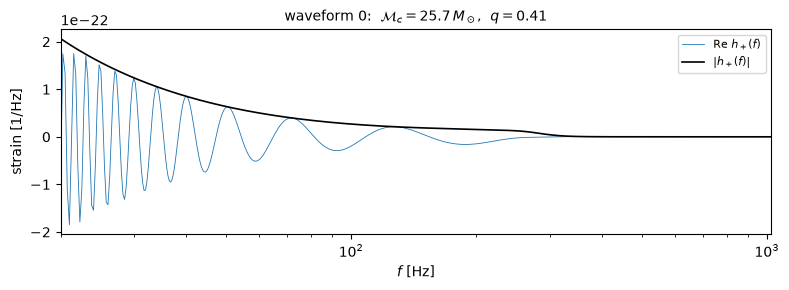

In [6]:
from dingo.gw.dataset import WaveformDataset

with tidy_paths():
    wfd = WaveformDataset(file_name=str(DEMO / "waveform_dataset.hdf5"))

print(f"{len(wfd)} waveforms, stored as {wfd.polarizations['h_plus'].shape[1]} "
      f"SVD coefficients each")
print(f"parameters: {list(wfd.parameters.columns)}")

# Indexing decompresses: coefficients times the stored basis, back on the frequency grid.
sample = wfd[0]
theta, h_plus = sample["parameters"], sample["waveform"]["h_plus"]
f = wfd.domain.sample_frequencies

plt.figure(figsize=(8, 3))
plt.plot(f, h_plus.real, lw=0.6, label=r"Re $h_+(f)$")
plt.plot(f, np.abs(h_plus), "k", lw=1.2, label=r"$|h_+(f)|$")
plt.xscale("log")
plt.xlim(20, 1024)
plt.xlabel("$f$ [Hz]")
plt.ylabel("strain [1/Hz]")
plt.title(rf"waveform 0:  $\mathcal{{M}}_c = {theta['chirp_mass']:.1f}\,M_\odot$,  "
          rf"$q = {theta['mass_ratio']:.2f}$", fontsize=10)
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()

### 3.2 The ASD dataset

Stage 2 of the diagram. `dingo_generate_asd_dataset` pulls strain from GWOSC and Welch-averages it. The
settings say *which* noise: run, detectors, how much data goes into one estimate. Production networks train
over a distribution of ASDs, so they stay robust to whatever state the detectors are in. This toy sets
`num_psds_max: 1` and pins one noise state, the one it will be asked to analyze. Section 4 comes back to what
that shortcut costs on real data.

Not run live: 130 MB per detector. It was run once, off-source, on the 1024 s ending 16 s before GW150914:

```
dingo_generate_asd_dataset --settings_file asd_dataset_settings.yaml \
    --data_dir training_data/asd_dataset \
    --time_segments_file training_data/asd_dataset/psd_time_segments_GW150914.pkl
```

Loading dataset from ~/Documents/Research/dingo-gw/tutorial-esa/dingo-training/bbh_11d_a100/training_data/asd_dataset/asds_O1.hdf5.


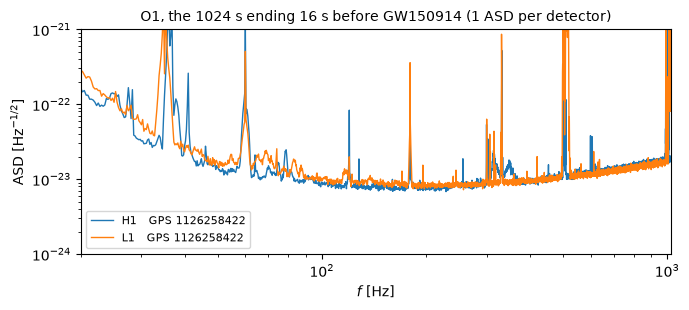

In [7]:
from dingo.gw.noise.asd_dataset import ASDDataset

show_file(SETTINGS / "asd_dataset_settings.yaml")

with tidy_paths():
    asds = ASDDataset(file_name=str(ASDS))
f = asds.domain.sample_frequencies

plt.figure(figsize=(7, 3.2))
for det, c in zip(["H1", "L1"], ["C0", "C1"]):
    plt.loglog(f, asds.asds[det][0], c, lw=1, label=f"{det}   GPS {asds.gps_times[det][0]:.0f}")
plt.xlim(20, 1024)
plt.ylim(1e-24, 1e-21)
plt.xlabel("$f$ [Hz]")
plt.ylabel(r"ASD [Hz$^{-1/2}$]")
plt.legend(fontsize=8)
plt.title(f"O1, the 1024 s ending 16 s before GW150914 ({len(asds.asds['H1'])} ASD per detector)", fontsize=10)
plt.tight_layout()

### 3.3 Training

Stage 3 of the diagram. `dingo_train` takes the waveform dataset, the ASDs and `train_settings.yaml`, and
writes checkpoints that carry all three. We launch it, read its settings file while it starts, then print the
log of the whole run: the settings DINGO resolved, the SVD it builds for the embedding network, the parameter
counts, and three epochs of loss.

In [8]:
TRAIN_LIVE = True                  # False -> read the log from the previous run instead
DEMO_LOG = DEMO / "train.log"

if TRAIN_LIVE:
    (DEMO / "asds_O1.hdf5").unlink(missing_ok=True)
    (DEMO / "asds_O1.hdf5").symlink_to(ASDS)
    shutil.rmtree(DEMO / "training", ignore_errors=True)   # a fresh run, not a resumed one
    (DEMO / "training").mkdir()
    proc = subprocess.Popen("dingo_train --settings_file train_settings.yaml --train_dir training",
                            shell=True, cwd=DEMO, stdout=DEMO_LOG.open("w"), stderr=subprocess.STDOUT)
    print(f"launched dingo_train, pid {proc.pid} -- leaving it running")

launched dingo_train, pid 38028 -- leaving it running


In [9]:
show_file(DEMO / "train_settings.yaml")

Four things worth pointing at.

- **`inference_parameters` is a list.** Delete a line and that parameter is marginalized over, with no code to
  change anywhere. There are eleven entries here. `chi_1` and `chi_2` are the components of the two black-hole
  spins along the orbital angular momentum, and they are on the list because the intrinsic prior in 3.1 samples
  them; take them out of both places and the same command trains a nine-parameter network on non-spinning
  binaries.
- **`extrinsic_prior` is applied at training time.** The dataset holds 5000 intrinsic waveforms, and the
  network sees each of them at a different sky position, distance, time and polarization every epoch. This is
  Part 1's noise-on-the-fly argument, extended to five more parameters.
- **`embedding_kwargs.svd`** is the piece Part 1 explicitly did without (`CONTEXT_DIM = 2 * N`, no embedding
  network). DINGO seeds the first layer with an SVD basis built from the training waveforms, then freezes it
  while the rest of the network settles.
- **`training` is a list of stages.** Production runs use two or three, with different learning rates and
  different ASD datasets, and `dingo_append_training_stage` adds one to a network that has already trained.

`posterior_model_type` is the single line you would change to swap Part 1's discrete flow for Part 2's
continuous one: `flow_matching` instead of `normalizing_flow`.

In [10]:
# Wait for the three epochs to finish, then print the log they wrote. In the session,
# this cell is the pause.
log = []
for _ in range(120):                      # 120 x 5 s = 10 minutes
    log = DEMO_LOG.read_text().splitlines() if DEMO_LOG.exists() else []
    if any(l.startswith("All training stages complete") for l in log):
        break
    time.sleep(5)
else:
    if any(l.startswith("Train Epoch") for l in log):
        print("[still running after 10 minutes -- the log so far]\n")
    else:
        print("[no loss lines after 10 minutes -- the trainer is slow or has failed]\n")

show_lines(log)

~/Documents/Research/dingo-gw/tutorial-esa/dingo-training/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Beginning new training run.
Loading dataset from waveform_dataset.hdf5.
Omitting data keys ['polarizations'].

Building SVD for initialization of embedding network.
Setting train transforms.
Omitting 
	AddWhiteNoiseComplex
	RepackageStrainsAndASDS
	SelectStandardizeRepackageParameters
	UnpackDict
	CropMaskStrainRandom
Loading dataset from asds_O1.hdf5.
Calculating new parameter standardizations.
Generating waveforms for embedding network SVD initialization.
...done. This took 0 s.
Generating SVD basis for ifo:
...H1 done.
...L1 done.
...this took 1 s.
Testing SVD basis matrices.
...H1:
n = 50
  Mean mismatch = 0.027002848096108388
  Standard deviation = 0.04066973749370369
  Max mismatch = 0.2762952598346565
  Median m

Three epochs on 5000 waveforms shows that the command works. It does not make a network. Everything from 3.4
onwards uses a network built by the same two commands on a GPU machine: 300 000 waveforms, then 400 epochs in
about four hours on one NVIDIA A100, with the best-validation checkpoint picked afterwards. Its settings files
are below, printed from the run directory that produced it, along with what the loss did.

In [11]:
print(f"# {str(RUN).replace(HOME, '~')}")
print("$ dingo_generate_dataset --settings_file waveform_dataset_settings.yaml \\")
print("      --out_file training_data/waveform_dataset.hdf5")
print("$ dingo_train --settings_file train_settings.yaml --train_dir training")
show_file(RUN / "waveform_dataset_settings.yaml")
show_file(RUN / "train_settings.yaml")

# history.txt has one row per epoch: epoch, training loss, validation loss, learning rate.
hist = np.loadtxt(RUN / "history.txt")
best = int(np.argmin(hist[:, 2]))
print(f"{len(hist)} epochs in history.txt")
print(f"  best validation loss  {hist[best, 2]:.4f}  at epoch {int(hist[best, 0])}")
print(f"  final epoch           {hist[-1, 2]:.4f}  at epoch {int(hist[-1, 0])}")
print(f"\n{MODEL.name} is the epoch-{int(hist[best, 0])} checkpoint, not the last one. Cosine annealing")
print("drives the learning rate to zero at epoch 400, and the validation loss wanders over the")
print("last few tens of epochs; early_stopping.patience is set high purely so that best_model.pt")
print("keeps being rewritten and there is a best epoch to pick.")

# ~/Documents/Research/dingo-gw/tutorial-esa/dingo-training/bbh_11d_a100
$ dingo_generate_dataset --settings_file waveform_dataset_settings.yaml \
      --out_file training_data/waveform_dataset.hdf5
$ dingo_train --settings_file train_settings.yaml --train_dir training


400 epochs in history.txt
  best validation loss  1.6996  at epoch 389
  final epoch           1.8122  at epoch 400

part2b_toy.pt is the epoch-389 checkpoint, not the last one. Cosine annealing
drives the learning rate to zero at epoch 400, and the validation loss wanders over the
last few tens of epochs; early_stopping.patience is set high purely so that best_model.pt
keeps being rewritten and there is a best epoch to pick.


| | the demo above | the network used below |
|---|---|---|
| waveforms | 5 000 | 300 000 |
| epochs | 3 | 400 |
| flow steps x hidden dim | 5 x 64 | 10 x 256 |
| embedding widths | 1024 → 128 | 2048 → 256 |
| embedding SVD size | 50 | 200 |
| batch size | 64 | 1024 |
| device | laptop CPU | one A100 |

Same file, same fields, same command, larger numbers. The domain, the waveform model, the intrinsic and
extrinsic priors, the eleven inference parameters and the ASD dataset are identical between the two. `device`
sits under `local:`, the block DINGO records but does not put into the network, so it does not change what is
being fitted. What separates the demo from the network below is scale, not kind.

### 3.4 Inference on an injection

Stage 4 of the diagram, and the one stage with no command line: `dingo_pipe` is the front end for real events,
and for an injection it is easier to call the same objects from Python. Inject a signal drawn from the
network's own training distribution and see whether it comes back. Nothing below specifies a prior, a domain,
a waveform model, a detector or a standardization, because `Injection.from_posterior_model_metadata` reads all
of it off the checkpoint.

In [12]:
import dingo.gw.injection as injection
from dingo.gw.inference.gw_samplers import GWSampler

with tidy_paths():
    inj = injection.Injection.from_posterior_model_metadata(pm.metadata)
    inj.asd = ASDDataset(file_name=str(ASDS), ifos=data_settings["detectors"])

# Seeded, so the numbers quoted in the text below are the numbers this cell prints.
np.random.seed(42)
torch.manual_seed(42)

# chi_1 and chi_2 are aligned spin components that the network infers, so they are set here
# like any other parameter. Small values, like GW150914's, well inside the prior.
theta = dict(chirp_mass=32.0, mass_ratio=0.8, chi_1=0.1, chi_2=0.05, theta_jn=2.3, phase=1.0,
             geocent_time=0.0, luminosity_distance=500.0, ra=1.2, dec=-1.1, psi=2.0)

print(f"network            {MODEL.name}")
print(f"inferred           {data_settings['inference_parameters']}")
print(f"injected           {theta}")
print(f"detectors / ASD    {data_settings['detectors']}  {ASDS.name}\n")

with tidy_paths():
    strain = inj.injection(theta)

    sampler = GWSampler(model=pm)
    sampler.context = strain
    sampler.event_metadata = {"injection_parameters": theta}
    sampler.run_sampler(num_samples=20_000, batch_size=20_000)

result = sampler.to_result()
print(result.samples.columns.tolist())

Setting spin_conversion_phase = None. Using phase parameter for conversion to cartesian spins.
Loading dataset from ~/Documents/Research/dingo-gw/tutorial-esa/dingo-training/bbh_11d_a100/training_data/asd_dataset/asds_O1.hdf5.
Updating ASDDataset domain to match data domain.
network            part2b_toy.pt
inferred           ['chirp_mass', 'mass_ratio', 'chi_1', 'chi_2', 'theta_jn', 'dec', 'ra', 'geocent_time', 'luminosity_distance', 'psi', 'phase']
injected           {'chirp_mass': 32.0, 'mass_ratio': 0.8, 'chi_1': 0.1, 'chi_2': 0.05, 'theta_jn': 2.3, 'phase': 1.0, 'geocent_time': 0.0, 'luminosity_distance': 500.0, 'ra': 1.2, 'dec': -1.1, 'psi': 2.0}
detectors / ASD    ['H1', 'L1']  asds_O1.hdf5

Running sampler to generate 20000 samples.


Done. This took 1.9 s.


['chirp_mass', 'mass_ratio', 'chi_1', 'chi_2', 'theta_jn', 'dec', 'ra', 'geocent_time', 'luminosity_distance', 'psi', 'phase', 'log_prob']


And the $\epsilon$ of Part 2a, as a one-liner. `importance_sample` rebuilds the likelihood from the settings
already inside the result, using the same waveform model, domain and ASD the network was trained with,
evaluates it at every sample, and attaches weights, a log evidence and a sample efficiency.

In [13]:
with tidy_paths():
    result.importance_sample(num_processes=1)
n_eff = result.sample_efficiency * len(result.samples)
print(f"log evidence      {result.log_evidence:.2f}")
print(f"sample efficiency {result.sample_efficiency:.3%}   "
      f"({n_eff:.0f} effective samples from {len(result.samples):,})")

# The proposal is poor, but is it wrong? Check the network's own credible intervals.
covered = [p for p in data_settings["inference_parameters"]
           if np.percentile(result.samples[p], 5) <= theta[p] <= np.percentile(result.samples[p], 95)]
print(f"injected value inside the network's 90% interval: "
      f"{len(covered)} of {len(data_settings['inference_parameters'])} parameters")

Setting spin_conversion_phase = None. Using phase parameter for conversion to cartesian spins.


Calculating 19894 likelihoods.


Done. This took 15.62 seconds.
log evidence      -8107.49
sample efficiency 0.102%   (20 effective samples from 20,000)
injected value inside the network's 90% interval: 11 of 11 parameters


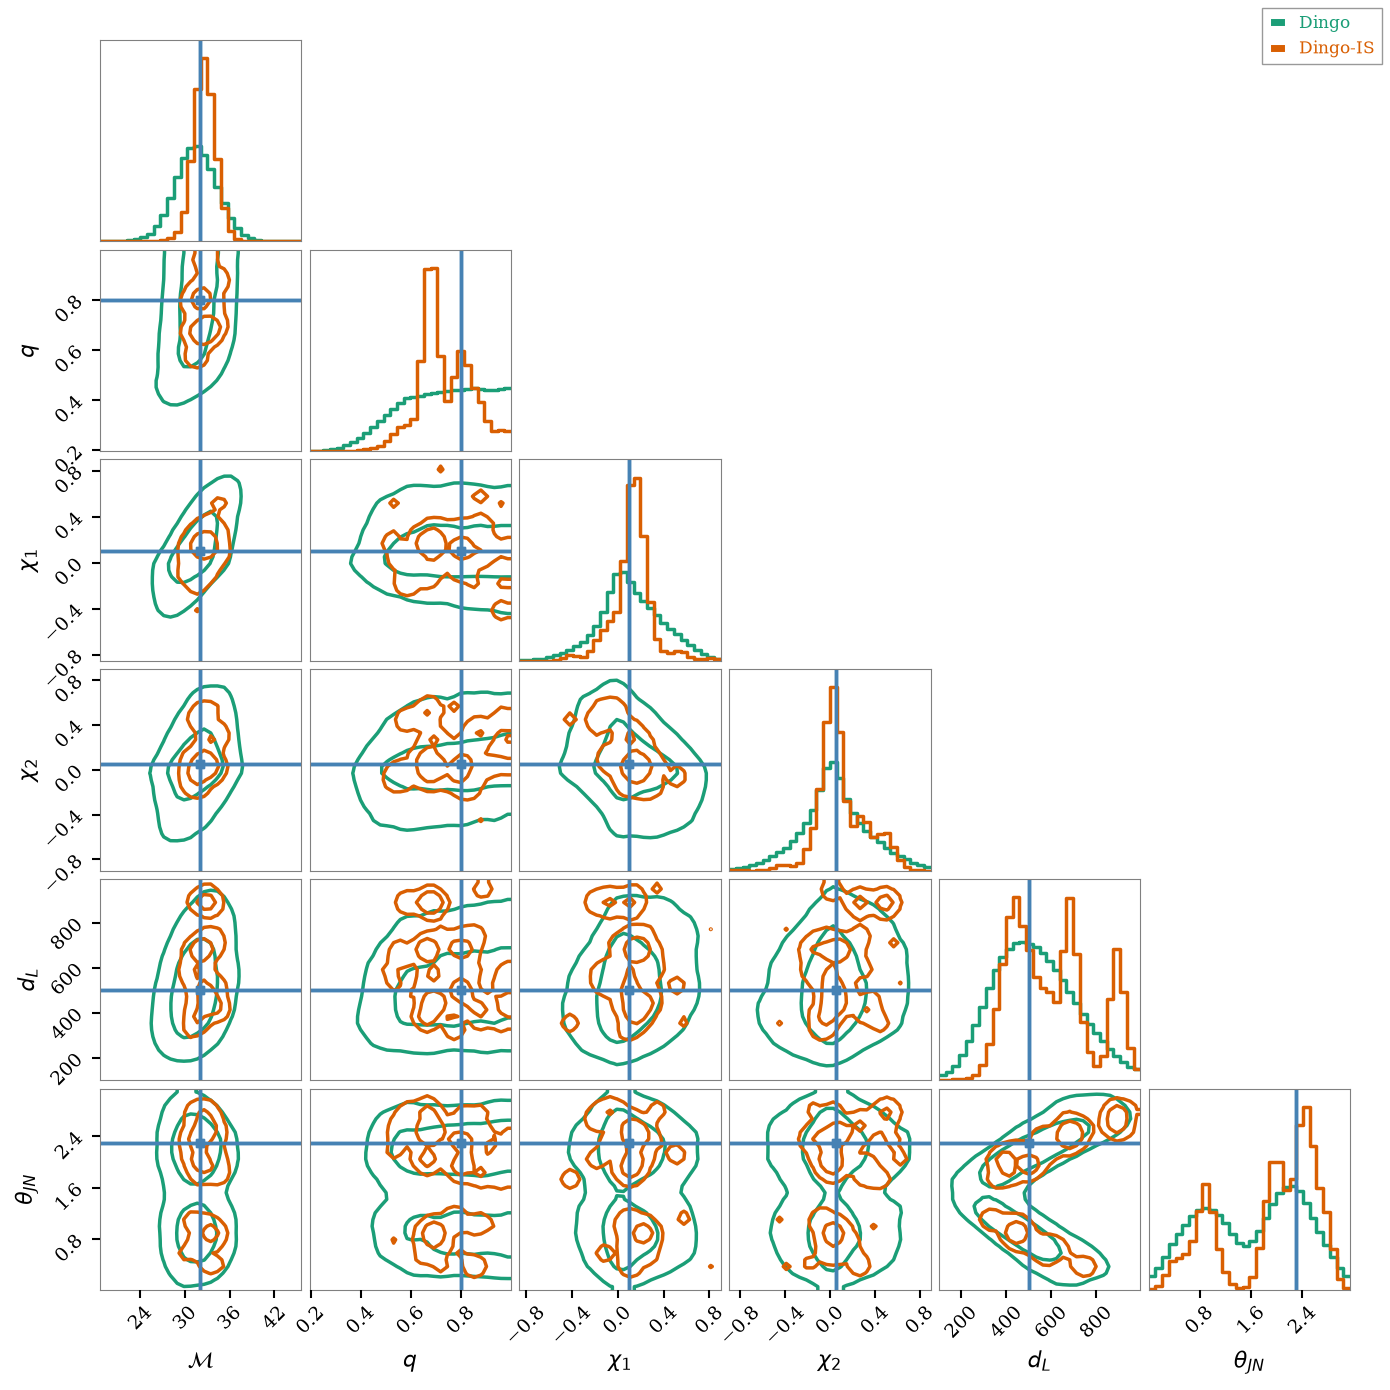

In [14]:
Path("figures").mkdir(exist_ok=True)
result.plot_corner(parameters=["chirp_mass", "mass_ratio", "chi_1", "chi_2",
                               "luminosity_distance", "theta_jn"],
                   filename="figures/part2b_injection_corner.png", legend_font_size=12)
plt.close("all")
Image("figures/part2b_injection_corner.png", width=760)

Green is the network, orange the importance-weighted posterior, blue the injected values. Where the two
disagree the weighted one is right in the limit of enough effective samples, and $\epsilon$ says
whether you have them. This is the diagnostic of
Part 2a, on a problem for which nobody wrote a likelihood by hand.

Read the two numbers in the cell above before you read the figure. $\epsilon = 0.102\%$, so the orange
contours are drawn from 20 effective samples rather than from 20 000: a couple of hundred is enough for a mean
and a width, a few thousand for a contour you would put in a paper, and twenty for neither. The green contours
are the ones to read, and they do the job. The injected value falls inside the network's own 90% credible
interval for all eleven parameters, spins included. That is one injection and not the P–P test of Part 1, but
it is the check to run before reading anything into $\epsilon$.

The network is therefore finding the signal while being a poor enough proposal that the exact correction is
out of reach. $\epsilon$ measures how far short of a production network it falls, and quoting it is cheaper
than arguing about it. Section 4 runs the same two commands on a real event, where the number is worse.

---
# 4. dingo_pipe

*(~5 min)*

Stage 5 of the diagram. `dingo_pipe` is the event front end: it takes an `.ini`, fetches the strain, estimates
the PSD, runs the network, importance samples, and writes a result file with plots. It is `bilby_pipe` with a
network where the stochastic sampler used to be, and it either submits to a cluster or runs locally. The whole
configuration for analyzing a real event is short enough to read.

In [15]:
show_file(SETTINGS / "GW150914.ini", lang="ini")

No prior, no waveform model, no frequency range, no reference time. `dingo_pipe` reads all of that off the
network and refuses to run if the data it fetches cannot be made to match. The one ugly line is
`request-cpus-importance-sampling = 1`, which pins a version-skew bug between dingo 0.9.8 and bilby_pipe 1.5;
the comment above it exists so nobody rediscovers it twice.

This file produced everything below. From cold it takes about 25 minutes, nearly all of that the GWOSC
download; with the O1 strain already cached the analysis is a couple of minutes, of which the network's
20 000 samples are a few seconds and the likelihood evaluations are the rest. The output ships with this
repository in `results/GW150914/`, so this section needs no network connection.

In [16]:
sh("ls -1 results/GW150914", cwd=Path.cwd());

$ ls -1 results/GW150914
GW150914_config_complete.ini
GW150914_data0_1126259462-4_importance_sampling_plot_corner.pdf
GW150914_data0_1126259462-4_importance_sampling_plot_weights.png
GW150914_data0_1126259462-4_importance_sampling.hdf5
GW150914_data0_1126259462-4_sampling.hdf5
[exit 0, 0 s]


In [17]:
from dingo.gw.result import Result

with tidy_paths():
    gw150914 = Result(file_name=str(next(RESULTS.glob("*importance_sampling.hdf5"))))
s = gw150914.samples
w = s["weights"].to_numpy() / s["weights"].sum()
n_eff = 1.0 / np.sum(w ** 2)

print(f"log evidence      {gw150914.log_evidence:.2f} +- {gw150914.log_evidence_std:.2f}")
print(f"sample efficiency {gw150914.sample_efficiency:.3%}   "
      f"({n_eff:.0f} effective samples from {len(s):,})\n")

# s.describe() would ignore the weights column and report the network's own moments.
print(f"{'':22s}{'network proposal':>22s}{'importance sampled':>24s}")
for p in ["chirp_mass", "mass_ratio", "luminosity_distance"]:
    x = s[p].to_numpy()
    mean = np.average(x, weights=w)
    std = np.sqrt(np.average((x - mean) ** 2, weights=w))
    print(f"{p:22s}{x.mean():11.2f} +-{x.std():8.2f}{mean:13.2f} +-{std:8.2f}")

Loading dataset from ~/Documents/Research/dingo-gw/tutorial-esa/lisa-npe-tutorial/results/GW150914/GW150914_data0_1126259462-4_importance_sampling.hdf5.
log evidence      -5423.71 +- 0.44
sample efficiency 0.026%   (5 effective samples from 20,000)

                            network proposal      importance sampled
chirp_mass                  31.19 +-    1.67        30.84 +-    0.69
mass_ratio                   0.66 +-    0.17         0.84 +-    0.08
luminosity_distance        366.44 +-  119.51       325.86 +-  102.33


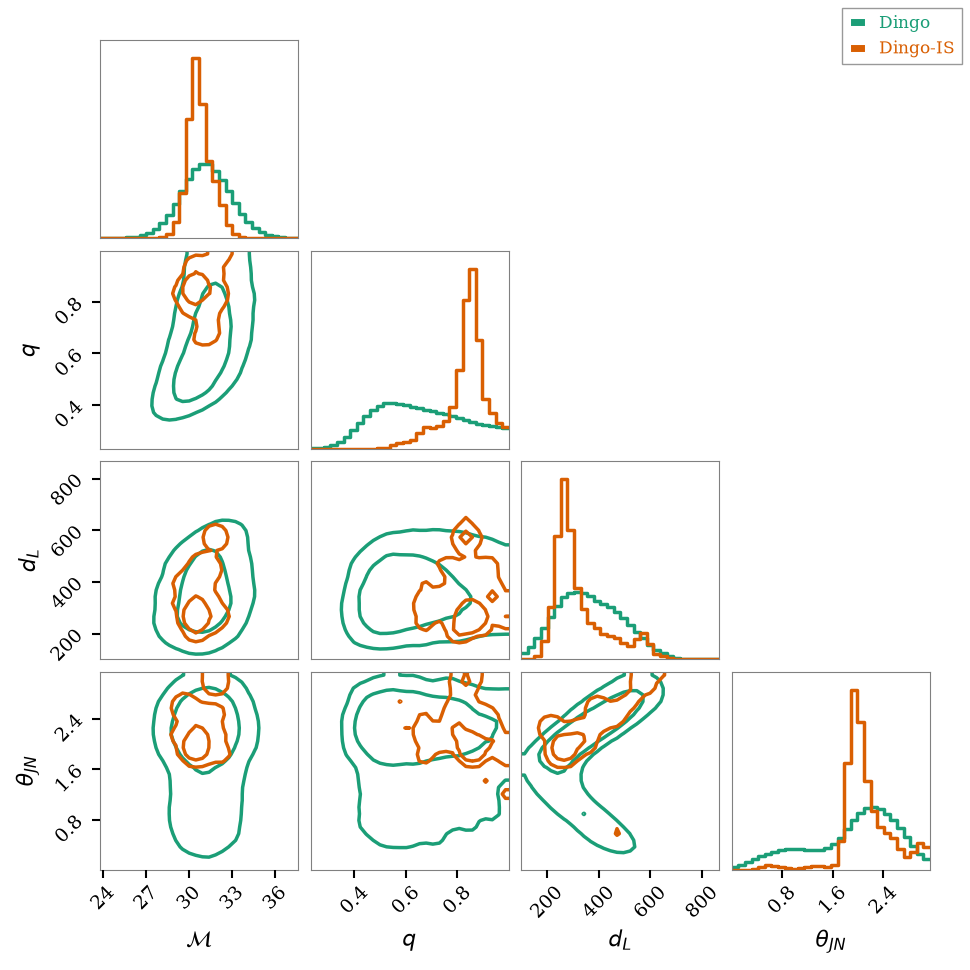

In [18]:
gw150914.plot_corner(parameters=["chirp_mass", "mass_ratio", "luminosity_distance", "theta_jn"],
                     filename="figures/part2b_GW150914_corner.png", legend_font_size=12)
plt.close("all")
Image("figures/part2b_GW150914_corner.png", width=640)

Green is the network, orange the importance-weighted result. At $\epsilon = 0.026\%$ the orange contours rest on five effective samples out of 20 000, and five
samples do not make a posterior. The right-hand column of the table is not a correction to the left-hand one;
it is noise with a mean and a width printed next to it. Reweighting moves the mass ratio toward the published
value in the table below and the distance away from it, and at five effective samples neither movement carries
information. So the reweighted GW150914 posterior is not the answer here, and this notebook does not offer it
as one.

That is what $\epsilon$ is for. Importance sampling is exact when it works and diagnoses itself when it does
not, and here it says the proposal is too poor to rescue. The tutorial has already seen the other case: Part
2a reaches 7% on the galactic-binary problem it was built for, and the production DINGO networks of
[Dax et al. (2022)](https://arxiv.org/abs/2210.05686) reach efficiencies orders of magnitude above this one on
exactly these events. Nothing about the method changed between there and here. What changed is how good the
proposal is.

The injection in 3.4 is the useful contrast. Twenty injections drawn from the training distribution with
different seeds give efficiencies between 0.008% and 0.67%, median 0.11%, about four times the 0.026% this
network manages on GW150914. The injections come from the distribution the network was trained on, and
GW150914 does not. One likely contributor is the ASD: `num_psds_max: 1` in 3.2 means this network saw exactly
one O1 noise realization per detector during training, so whatever the real event's PSD does differently is
unmodelled, and the mismatch is paid for in $\epsilon$. Widening the ASD distribution is one of the first things a production
run does.

### Against the public LVC posterior

The figure above sets the network against its own reweighting, and $\epsilon$ has just ruled that out as a
reference. An external one is available. GWTC-1 released posterior samples for GW150914, and
`results/GW150914_GWTC-1.hdf5` holds them. Three things to keep in mind while reading the overlay.

- **The waveform models differ.** GWTC-1 published no aligned-spin sample set. Its IMRPhenomPv2 samples come
  from a precessing model, and this network is aligned-spin IMRPhenomD. GW150914 has small measured spins and
  near-equal masses, which is the corner of parameter space where precession matters least, so the comparison
  is informative but approximate. The masses, the distance and the sky position are the parameters least
  exposed to the difference; `chi_1`, `chi_2`, `psi` and `phase` are not comparable at all and are left off.
- **The priors differ.** This network's distance prior is uniform on [100, 1000] Mpc. The GWTC-1 prior samples
  in the same file run to 2.07 Gpc with a median of 1.64 Gpc, which is what a uniform-in-comoving-volume prior
  looks like. A prior that puts more weight at large distance pulls the distance posterior out with it, so a
  shift in the distance marginal is not by itself an error in the network.
- **These are the raw NPE samples.** No weights, for the reason given above.

network mass_ratio: median 0.643, max 1.0045, 0.09% of samples above 1


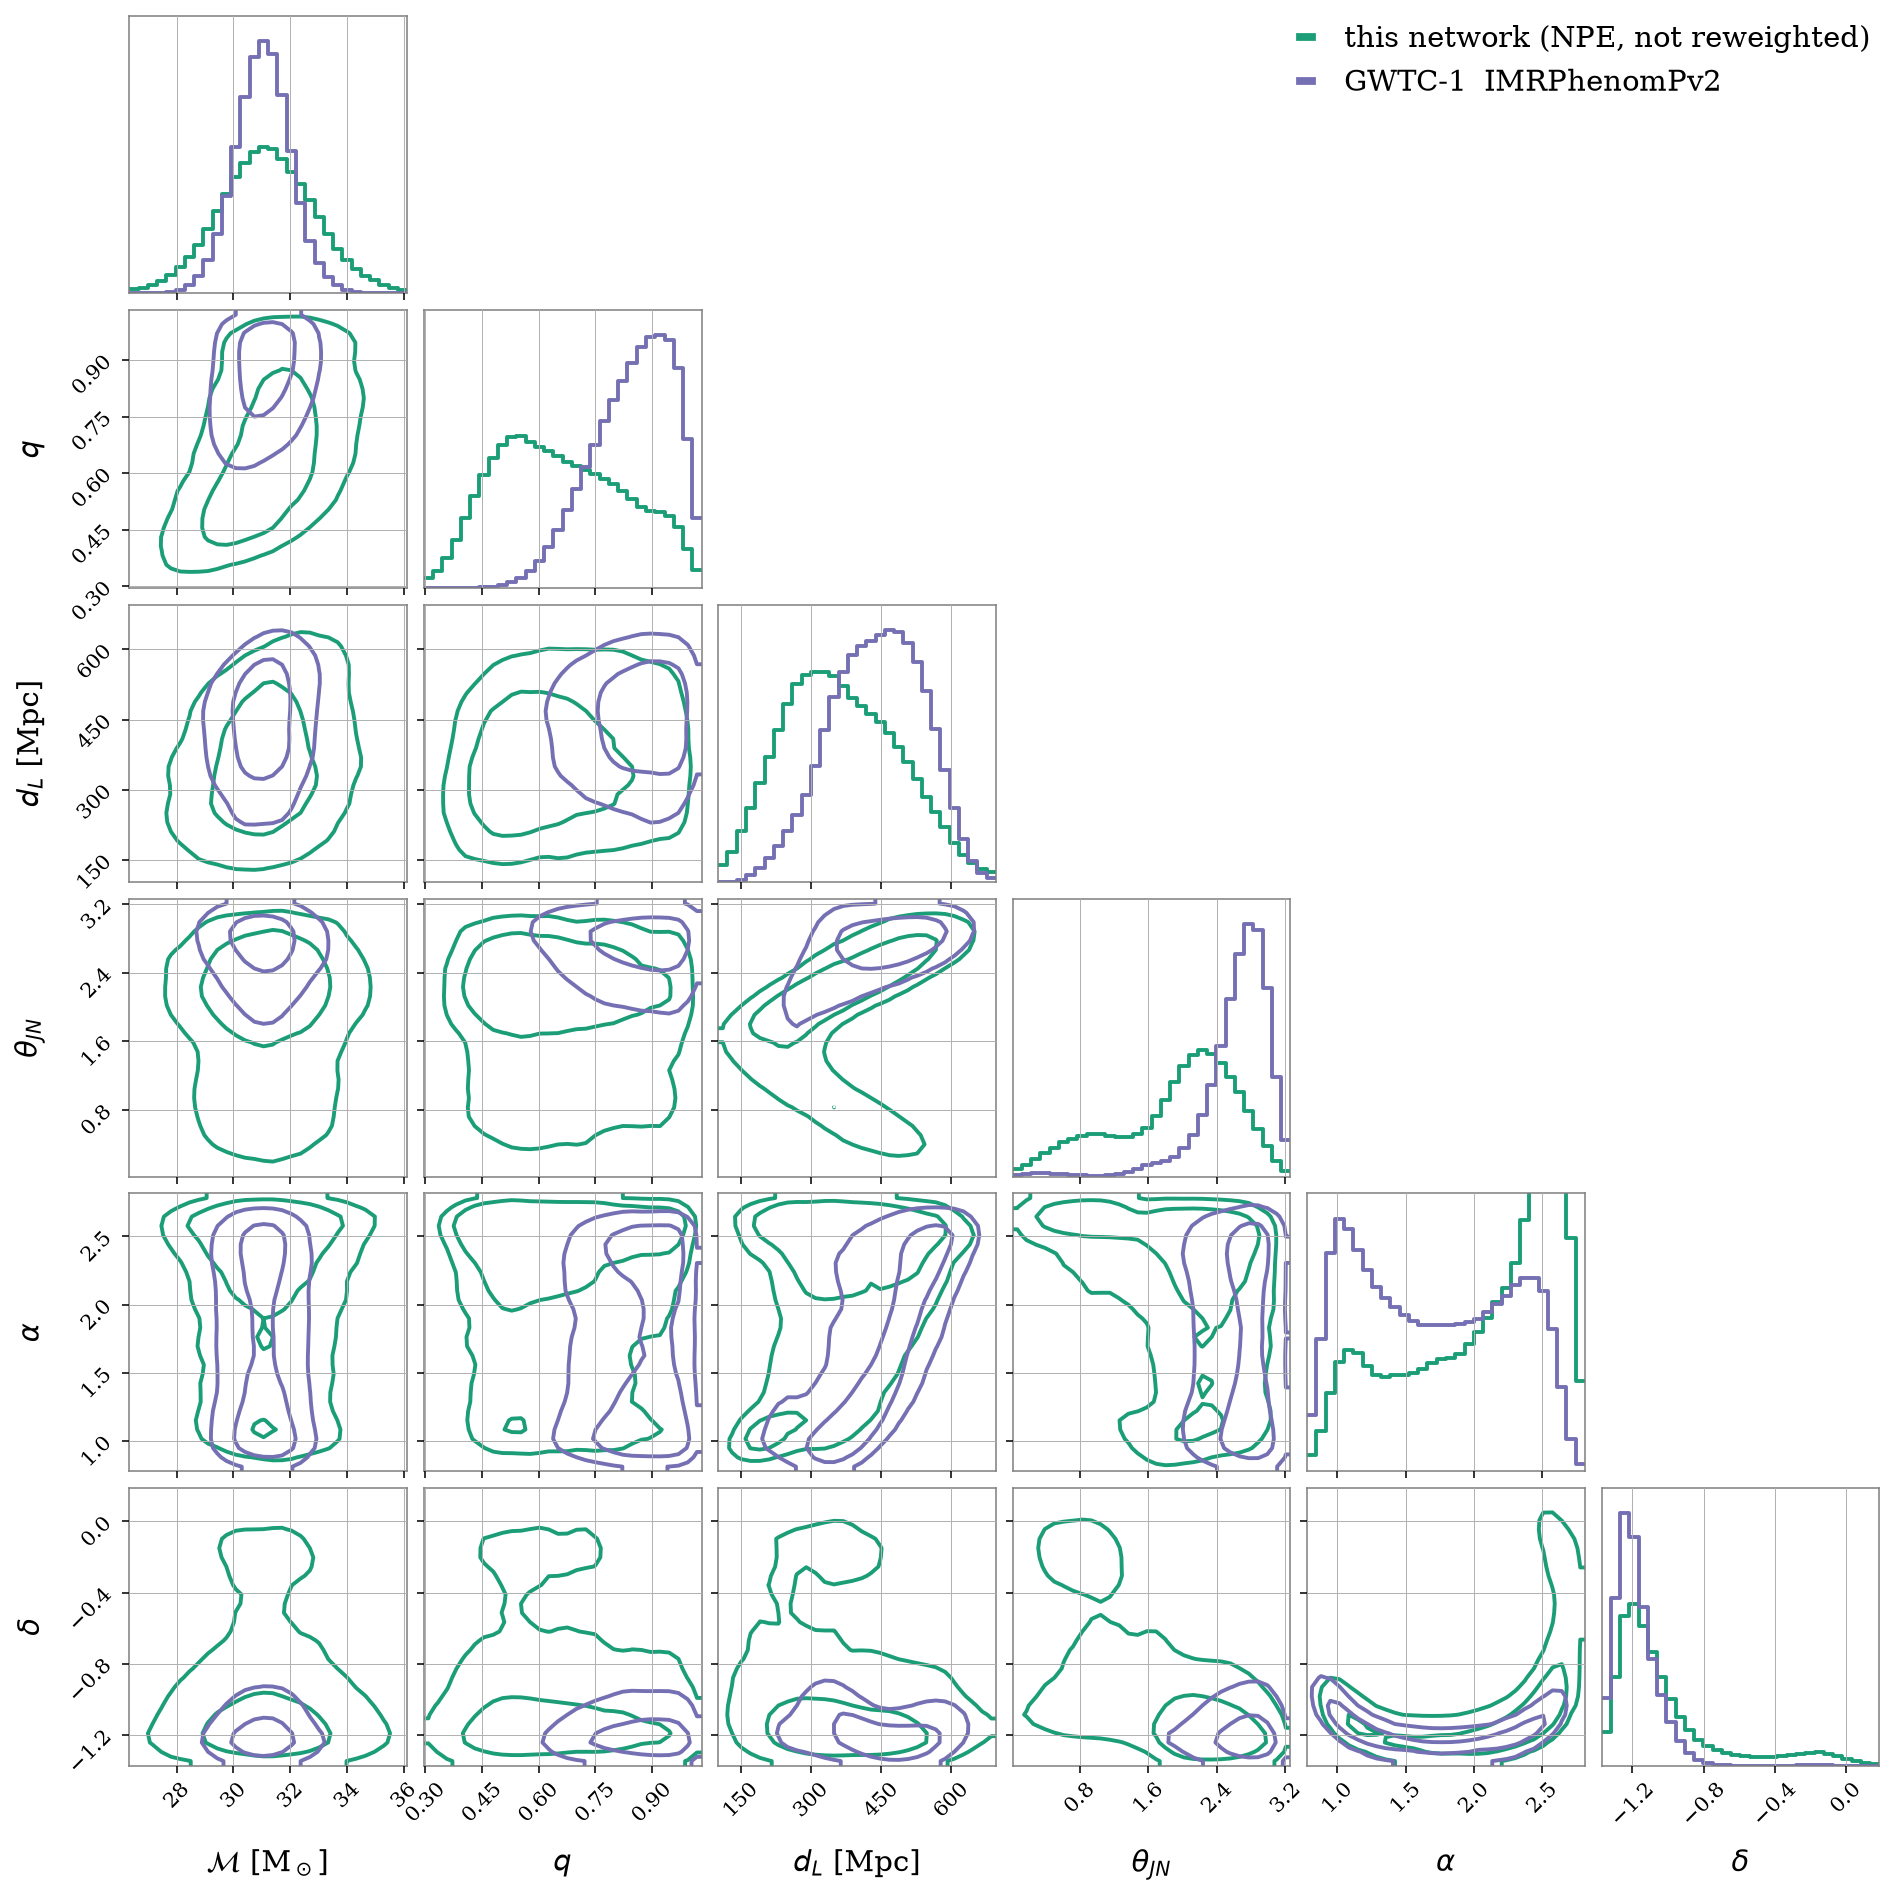

| median and 90% credible interval | this network | GWTC-1 IMRPhenomPv2 |
|---|---|---|
| chirp mass [M<sub>&#9737;</sub>] | **31.17**  [28.47, 33.96] | **31.06**  [29.52, 32.55] |
| mass ratio | **0.64**  [0.41, 0.95] | **0.86**  [0.66, 0.99] |
| luminosity distance [Mpc] | **357**  [184, 573] | **445**  [274, 589] |
| &theta;<sub>JN</sub> [rad] | **2.07**  [0.55, 2.84] | **2.72**  [1.89, 3.04] |
| right ascension [rad] | **2.26**  [1.05, 2.67] | **1.69**  [0.94, 2.55] |
| declination [rad] | **-1.12**  [-1.27, -0.19] | **-1.21**  [-1.28, -0.98] |

distance prior, this network:  bilby.core.prior.Uniform(minimum=100.0, maximum=1000.0, name='luminosity_distance')
distance prior, GWTC-1 release: samples span [69, 2066] Mpc, median 1643 Mpc


In [19]:
import corner
import h5py
import matplotlib as mpl

# GWTC-1 ships component masses and cos(theta_jn); dingo's parameters are derived from those.
with h5py.File(GWTC1, "r") as f:
    lvc = f["IMRPhenomPv2_posterior"][:]
    lvc_prior_dl = f["prior"][:]["luminosity_distance_Mpc"]
m1, m2 = lvc["m1_detector_frame_Msun"], lvc["m2_detector_frame_Msun"]

# Both sides have to mean the same thing by "mass ratio" before anything is overlaid. The
# release orders its components m2 <= m1, so its ratio is m2/m1. dingo's is the same, and
# its samples say so rather than us assuming it: the flow has no hard wall at q = 1, but
# its mass_ratio piles up below 1 and only a handful of samples cross.
q = s["mass_ratio"].to_numpy()
assert (m2 <= m1).all()
assert np.median(q) < 1.0 and np.mean(q > 1.0) < 0.005
print(f"network mass_ratio: median {np.median(q):.3f}, max {q.max():.4f}, "
      f"{np.mean(q > 1.0):.2%} of samples above 1")

LVC = {"chirp_mass": (m1 * m2) ** 0.6 / (m1 + m2) ** 0.2,
       "mass_ratio": m2 / m1,
       "luminosity_distance": lvc["luminosity_distance_Mpc"],
       "theta_jn": np.arccos(lvc["costheta_jn"]),
       "ra": lvc["right_ascension"],
       "dec": lvc["declination"]}
PARS = list(LVC)
LABELS = [r"$\mathcal{M}$ [M$_\odot$]", r"$q$", r"$d_L$ [Mpc]",
          r"$\theta_{JN}$", r"$\alpha$", r"$\delta$"]

X = np.column_stack([s[p].to_numpy() for p in PARS])   # ours, unweighted
Y = np.column_stack([LVC[p] for p in PARS])

# Axes hold the central 99% of both sets. A fraction of a per cent of the network's sky
# probability sits opposite the rest, and drawing to the extremes flattens everything else.
rng = []
for i in range(len(PARS)):
    lo = min(np.percentile(X[:, i], 0.5), np.percentile(Y[:, i], 0.5))
    hi = max(np.percentile(X[:, i], 99.5), np.percentile(Y[:, i], 99.5))
    pad = 0.05 * (hi - lo)
    rng.append((lo - pad, hi + pad))

NET, REF = "#1b9e77", "#7570b3"     # the green dingo draws the network in, and a second hue
kw = dict(smooth=1.0, smooth1d=1.0, plot_datapoints=False, plot_density=False,
          plot_contours=True, levels=[0.5, 0.9], bins=30, no_fill_contours=True,
          range=rng, labels=LABELS)
with mpl.rc_context({"font.family": "serif", "lines.linewidth": 2.0}):
    # Equal total weight per set, so the 1D marginals are on the same scale despite
    # 20 000 samples on one side and 40 836 on the other.
    fig = corner.corner(X, color=NET, weights=np.full(len(X), 1 / len(X)), **kw)
    corner.corner(Y, color=REF, fig=fig, weights=np.full(len(Y), 1 / len(Y)), **kw)
    for ax in fig.get_axes():
        ax.tick_params(labelsize=11)
        ax.xaxis.label.set_size(15)
        ax.yaxis.label.set_size(15)
    fig.legend(handles=[plt.Line2D([], [], color=NET, lw=4, label="this network (NPE, not reweighted)"),
                        plt.Line2D([], [], color=REF, lw=4, label="GWTC-1  IMRPhenomPv2")],
               loc="upper right", fontsize=15, frameon=False, bbox_to_anchor=(0.98, 0.98))
    fig.subplots_adjust(wspace=0.06, hspace=0.06)
    fig.savefig("figures/part2b_GW150914_vs_GWTC1.png", dpi=140, bbox_inches="tight")
plt.close("all")
display(Image("figures/part2b_GW150914_vs_GWTC1.png", width=860))

FMT = {"chirp_mass": ".2f", "mass_ratio": ".2f", "luminosity_distance": ".0f",
       "theta_jn": ".2f", "ra": ".2f", "dec": ".2f"}
NAME = {"chirp_mass": "chirp mass [M<sub>&#9737;</sub>]", "mass_ratio": "mass ratio",
        "luminosity_distance": "luminosity distance [Mpc]", "theta_jn": "&theta;<sub>JN</sub> [rad]",
        "ra": "right ascension [rad]", "dec": "declination [rad]"}


def med90(x, fmt):
    """Median and 90% interval of x, formatted for a Markdown table cell."""
    lo, mid, hi = np.percentile(x, [5, 50, 95])
    return f"**{mid:{fmt}}**  [{lo:{fmt}}, {hi:{fmt}}]"


rows = ["| median and 90% credible interval | this network | GWTC-1 IMRPhenomPv2 |", "|---|---|---|"]
for i, p in enumerate(PARS):
    rows.append(f"| {NAME[p]} | {med90(X[:, i], FMT[p])} | {med90(Y[:, i], FMT[p])} |")
display(Markdown("\n".join(rows)))

print(f"distance prior, this network:  {data_settings['extrinsic_prior']['luminosity_distance']}")
print(f"distance prior, GWTC-1 release: samples span "
      f"[{lvc_prior_dl.min():.0f}, {lvc_prior_dl.max():.0f}] Mpc, median {np.median(lvc_prior_dl):.0f} Mpc")

The chirp mass is the test that means the most, because it is the parameter a short binary-black-hole signal
constrains best and the one least disturbed by either caveat above. The network puts it at 31.17 M<sub>&#9737;</sub>
against GWTC-1's 31.06, with a 90% interval about twice as wide, [28.47, 33.96] against [29.52, 32.55]. The
network agrees on where the chirp mass is and is less certain about it than the reference analysis, which is
what a small network trained for four hours should look like. Declination agrees too: −1.12 against −1.21,
with both credible intervals covering the other's median. The α–δ panel shows both tracing the same arc of
sky, the ring the H1–L1 time delay allows.

Three parameters sit further apart, though in two of the three neither analysis excludes the other. Mass
ratio: 0.64 [0.41, 0.95] against 0.86 [0.66, 0.99]. This is the one real disagreement — the network's median
falls just below GWTC-1's 90% interval, which starts at 0.66, although GWTC-1's median sits comfortably inside
the network's. Distance: 357 [184, 573] Mpc against 445 [274, 589] Mpc. Inclination: 2.07 [0.55, 2.84] rad
against 2.72 [1.89, 3.04] rad. In both of those each median lies inside the other's 90% interval, so what has
moved is the bulk of the distribution rather than the conclusion. Distance and inclination are also the pair
the prior difference acts on hardest: they are degenerate with each other, and the two analyses weight large
distances differently. How much of the gap is prior and how much is the network is a question importance
sampling would settle, and at $\epsilon = 0.026\%$ it cannot settle it here.

The comparison is worth exactly what it measures: a four-hour network on 11 parameters recovers GW150914's
chirp mass and its position on the sky, and is looser and somewhat displaced on mass ratio, distance and
inclination. That is a demonstration of a pipeline rather than a measurement of a black hole.

The four commands ran on a real event, on real O1 strain the network had never seen, and returned a posterior,
an evidence and an efficiency, with no stochastic sampler anywhere in the loop. The pipeline is the production
one; the network is not. Scaling it up means larger numbers in the same fields and a GPU week rather than a
GPU afternoon.

Those same fields, scaled, gave the catalog analyses of Dax et al. (2021, 2023), and DINGO-BNS (2024), where a
chirp-mass proxy conditions the network exactly as `df_hat` did and a binary-neutron-star posterior arrives
about a second after merger, before the signal has finished arriving. For LISA, see Spadaro et al.,
[arXiv:2603.20431](https://arxiv.org/abs/2603.20431), presented this afternoon. The `dingo.gw.inference`
internals are being restructured; the settings files and the command line are stable.

### References

- Dax et al., [Real-time gravitational-wave science with neural posterior estimation](https://arxiv.org/abs/2106.12594) (2021)
- Dax et al., [Neural importance sampling for rapid and reliable gravitational-wave inference](https://arxiv.org/abs/2210.05686) (2022) — the $\epsilon$ of Part 2a
- Dax et al., [Real-time gravitational-wave inference for binary neutron stars using machine learning](https://arxiv.org/abs/2407.09602) (2024)
- Abbott et al., [GWTC-1](https://arxiv.org/abs/1811.12907) (2019) — the posterior samples overlaid above, from the [public release](https://dcc.ligo.org/LIGO-P1800370/public)
- [dingo-gw.readthedocs.io](https://dingo-gw.readthedocs.io/) — the toy example this notebook is built on